# 心臓病予測モデル（Heart Disease Prediction）

このノートブックでは、Kaggle Playground Series S6E2のデータを使用して、心臓病の有無を予測する機械学習モデルを構築します。

## 目次
1. 環境構築
2. ライブラリのインポート
3. データの読み込み
4. データの確認
5. 探索的データ分析（EDA）
6. 特徴量エンジニアリング
7. モデル学習（LightGBM）
8. 特徴量重要度の分析
9. ハイパーパラメータチューニング（Optuna）
10. 最終モデルの学習と保存

## 1. 環境構築

Google Colab環境で必要なライブラリをインストールします。
- **LightGBM**: GPU対応のGradient Boostingライブラリ
- **Optuna**: ハイパーパラメータ自動最適化フレームワーク

In [ ]:
# LightGBMのGPU版をインストール
!pip install lightgbm --install-option=--gpu


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: --install-option


In [ ]:
# Optunaをインストール（ハイパーパラメータ最適化用）
!pip install optuna

## 2. ライブラリのインポート

データ処理、可視化、機械学習に必要なライブラリをインポートします。

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import lightgbm as lgb
from itertools import combinations
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

## 3. データの読み込み

Google Drive上のKaggleコンペティションデータを読み込みます。
- `train.csv`: 学習用データ
- `test.csv`: テスト用データ（提出用）

In [ ]:
train_data = pd.read_csv('./playground-series-s6e2/train.csv')
test_data = pd.read_csv('./playground-series-s6e2/test.csv')

## 4. データの確認

読み込んだデータの先頭5行を確認します。

In [5]:
train_data.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


## 5. データの前処理

### 5.1 ターゲット変数のエンコーディング
`Heart Disease`列を数値に変換します（Presence → 1, Absence → 0）。

In [6]:
train_data['Heart Disease'] = train_data['Heart Disease'].map({'Presence': 1, 'Absence': 0})

## 6. 探索的データ分析（EDA）

### 6.1 相関行列の可視化
特徴量間の相関関係をヒートマップで確認し、Heart Diseaseとの相関が強い変数を特定します。

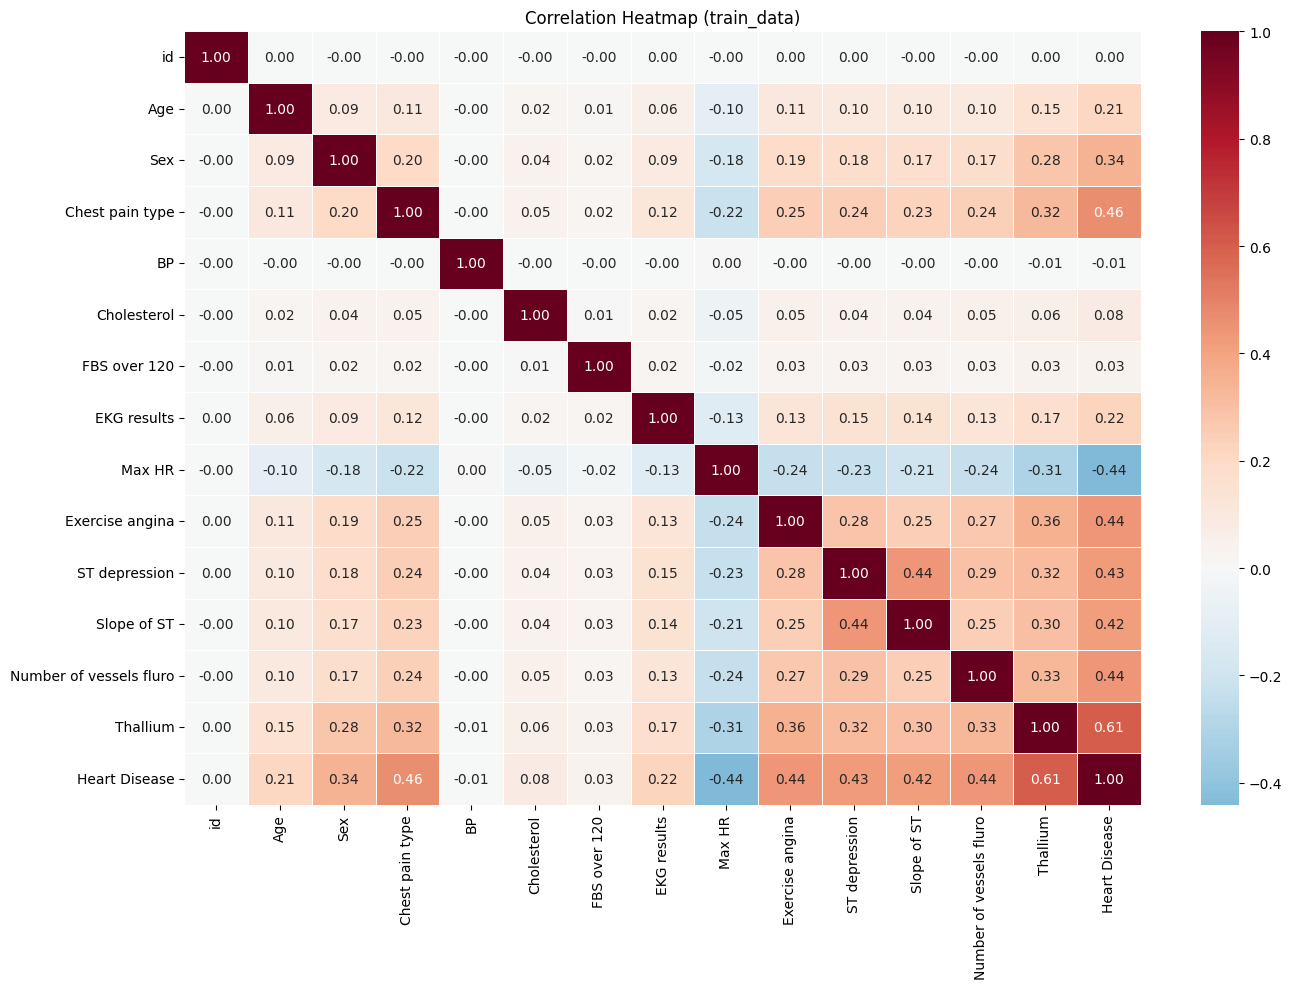

【Heart Disease との相関係数（強い順）】
Heart Disease              1.000000
Thallium                   0.605776
Chest pain type            0.460684
Exercise angina            0.441864
Number of vessels fluro    0.438604
ST depression              0.430641
Slope of ST                0.415050
Sex                        0.342446
EKG results                0.218961
Age                        0.212091
Cholesterol                0.082753
FBS over 120               0.033570
id                         0.000209
BP                        -0.005181
Max HR                    -0.440985
Name: Heart Disease, dtype: float64


In [7]:
# 3. 相関行列の計算
corr_matrix = train_data.corr()

# 4. ヒートマップの描画
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix,
            annot=True,      # マス目に数値を表示
            cmap='RdBu_r',   # 赤(正)〜白(無)〜青(負)の色分け
            fmt='.2f',       # 小数点2桁
            linewidths=0.5,
            center=0)        # 0を基準色にする

plt.title('Correlation Heatmap (train_data)')
plt.tight_layout()
plt.show()

# --- おまけ：Heart Diseaseとの相関が強い順に数値を表示 ---
if 'Heart Disease' in corr_matrix.columns:
    print("【Heart Disease との相関係数（強い順）】")
    print(corr_matrix['Heart Disease'].sort_values(ascending=False))
else:
    print("警告: 'Heart Disease' という列名が見つかりません。列名を確認してください。")

## 7. 特徴量エンジニアリング

より予測精度を高めるため、既存の特徴量を組み合わせた新しい特徴量を作成します。

### 7.1 医学的知見に基づく特徴量
- **Heart_Load**: 心負荷（最大心拍数 × 血圧）
- **Age_BP**: 加齢×血圧リスク
- **Vessel_ST**: 血管異常×心電図異常

In [8]:
# 新しい特徴量（項目）の作成
train_data['Heart_Load'] = train_data['Max HR'] * train_data['BP']          # 心負荷
train_data['Age_BP'] = train_data['Age'] * train_data['BP']                # 加齢×血圧リスク
train_data['Vessel_ST'] = train_data['Number of vessels fluro'] * train_data['ST depression'] # 血管異常×心電図

# 作成した新項目と Heart Disease の相関を確認
new_features = ['Heart_Load', 'Age_BP', 'Vessel_ST', 'Heart Disease']
print(train_data[new_features].corr()['Heart Disease'].sort_values(ascending=False))

Heart Disease    1.000000
Vessel_ST        0.371104
Age_BP           0.166076
Heart_Load      -0.326279
Name: Heart Disease, dtype: float64


### 7.2 リスク指標の作成
- **High_Risk_Combo**: 複数の危険因子が重なるケースを検出
- **HR_Efficiency**: 年齢に対する心拍効率（予測最大心拍数との比較）

In [9]:
# 1. 複数の強力な予兆があるか？（タリウム異常 且つ 血管異常）
# Thallium と Number of vessels fluro が共に高い人を 1 とする
train_data['High_Risk_Combo'] = ((train_data['Thallium'] > 2) & (train_data['Number of vessels fluro'] > 0)).astype(int)

# 2. 身体能力が年齢基準を下回っているか？（年齢のわりに最大心拍数が低い）
# 予測最大心拍数 (220-Age) に対して、実際の Max HR が低いほどリスク
train_data['HR_Efficiency'] = train_data['Max HR'] / (220 - train_data['Age'])

# 再度、相関をチェック
check_cols = ['High_Risk_Combo', 'HR_Efficiency', 'Heart Disease']
print(train_data[check_cols].corr()['Heart Disease'].sort_values(ascending=False))

Heart Disease      1.000000
High_Risk_Combo    0.454338
HR_Efficiency     -0.343383
Name: Heart Disease, dtype: float64


### 7.3 組み合わせ特徴量の自動生成
重要な数値特徴量同士の掛け算による組み合わせ特徴量を自動生成します。

In [10]:
# 1. 組み合わせたい列を選択（以前重要だった項目）
target_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']

# 2. 掛け算の組み合わせ（ArithmeticCombinations相当）を自作
def generate_combinations(df, cols):
    new_df = df.copy()
    # 列の2つずつの組み合わせを取得
    for col1, col2 in combinations(cols, 2):
        # 新しい列名を作成（例: Age_x_BP）
        new_col_name = f"{col1}_x_{col2}"
        # 掛け算を実行
        new_df[new_col_name] = df[col1] * df[col2]
    return new_df

# 3. 実行
train_data_enriched = generate_combinations(train_data, target_cols)

# 確認
print(f"追加された列の数: {len(train_data_enriched.columns) - len(train_data.columns)}")
print(train_data_enriched.head())

追加された列の数: 10
   id  Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  EKG results  \
0   0   58    1                4  152          239             0            0   
1   1   52    1                1  125          325             0            2   
2   2   56    0                2  160          188             0            2   
3   3   44    0                3  134          229             0            2   
4   4   58    1                4  140          234             0            2   

   Max HR  Exercise angina  ...  Age_x_BP  Age_x_Cholesterol  Age_x_Max HR  \
0     158                1  ...      8816              13862          9164   
1     171                0  ...      6500              16900          8892   
2     151                0  ...      8960              10528          8456   
3     150                0  ...      5896              10076          6600   
4     125                1  ...      8120              13572          7250   

   Age_x_ST depression  BP_x_Ch

## 8. モデル学習（LightGBM）

作成した特徴量を使用してLightGBMモデルを学習します。
- データを訓練用（80%）とテスト用（20%）に分割
- デフォルトパラメータでベースラインモデルを構築

In [11]:
# 学習データの準備
# id や ターゲットを除外
X = train_data_enriched.drop(columns=['Heart Disease', 'id'], errors='ignore')
y = train_data_enriched['Heart Disease']

# 訓練用とテスト用に分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# モデルの作成と学習
clf = lgb.LGBMClassifier()
clf.fit(X_train, y_train)

# 予測と評価
y_pred = clf.predict(X_test)
print(f"正解率 (Accuracy): {accuracy_score(y_test, y_pred):.4f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 226018, number of negative: 277982
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.073013 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3831
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448448 -> initscore=-0.206942
[LightGBM] [Info] Start training from score -0.206942
正解率 (Accuracy): 0.8867


## 9. 特徴量重要度の分析

モデルがどの特徴量を重視して予測しているかを確認します。

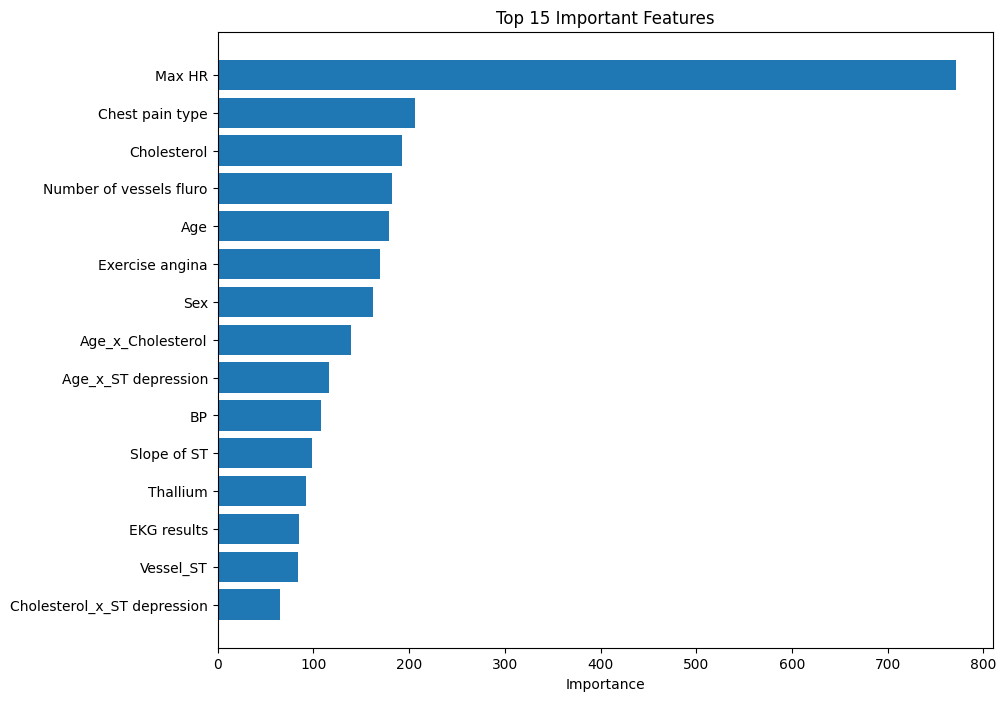

                    feature  importance
7                    Max HR         771
2           Chest pain type         206
4               Cholesterol         193
11  Number of vessels fluro         182
0                       Age         179
8           Exercise angina         170
1                       Sex         162
19        Age_x_Cholesterol         139
21      Age_x_ST depression         116
3                        BP         108


In [12]:
# 特徴量の重要度を取得
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': clf.feature_importances_
}).sort_values(by='importance', ascending=False)

# グラフ表示
plt.figure(figsize=(10, 8))
plt.barh(importances['feature'][:15][::-1], importances['importance'][:15][::-1])
plt.xlabel('Importance')
plt.title('Top 15 Important Features')
plt.show()

print(importances.head(10))

## 10. ハイパーパラメータチューニング（Optuna）

Optunaを使用してLightGBMのハイパーパラメータを自動最適化します。
50回の試行を行い、最も精度の高いパラメータ設定を探索します。

In [13]:
import optuna

# 1. データの準備（今の29個の特徴量が入った X と y を使用）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def objective(trial):
    # Optunaに試してもらうパラメータの範囲を指定
    param = {
        'objective': 'binary',
        'metric': 'binary_error',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 2, 256),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'device': 'gpu',
        # パラメータに追加
        'n_jobs': -1  # 利用可能なすべてのCPUコアを使用
    }

    # モデルの学習
    gbm = lgb.LGBMClassifier(**param)
    gbm.fit(X_train, y_train)

    # 予測と評価（精度を返す）
    preds = gbm.predict(X_test)
    accuracy = accuracy_score(y_test, preds)
    return accuracy

# 2. 最適化の実行
study = optuna.create_study(direction='maximize') # 精度を最大化したい
study.optimize(objective, n_trials=50) # 50回試行

# 3. 結果の表示
print('Best trial:')
trial = study.best_trial
print(f'  Value: {trial.value:.4f}')
print('  Params: ')
for key, value in trial.params.items():
    print(f'    {key}: {value}')

[I 2026-02-17 02:12:11,109] A new study created in memory with name: no-name-0d62a7f9-d77e-4f98-beb2-6aa77340d9a7
[I 2026-02-17 02:12:27,757] Trial 0 finished with value: 0.886015873015873 and parameters: {'lambda_l1': 0.22561416337138976, 'lambda_l2': 6.340053753059327e-07, 'num_leaves': 188, 'feature_fraction': 0.42968383041515174, 'bagging_fraction': 0.4963424575812719, 'bagging_freq': 1, 'min_child_samples': 25}. Best is trial 0 with value: 0.886015873015873.
[I 2026-02-17 02:12:43,078] Trial 1 finished with value: 0.8862222222222222 and parameters: {'lambda_l1': 1.0997039991840702e-05, 'lambda_l2': 1.4925300275799336e-05, 'num_leaves': 170, 'feature_fraction': 0.7017368711692928, 'bagging_fraction': 0.7309005869035423, 'bagging_freq': 5, 'min_child_samples': 40}. Best is trial 1 with value: 0.8862222222222222.
[I 2026-02-17 02:12:51,959] Trial 2 finished with value: 0.8859365079365079 and parameters: {'lambda_l1': 1.1148704572001764e-08, 'lambda_l2': 0.001295553363040303, 'num_lea

Best trial:
  Value: 0.8869
  Params: 
    lambda_l1: 0.2362823923963353
    lambda_l2: 2.011363505058181
    num_leaves: 52
    feature_fraction: 0.7705493967299117
    bagging_fraction: 0.5269424796532862
    bagging_freq: 1
    min_child_samples: 87


## 11. 最終モデルの学習と保存

Optunaで見つけた最適なパラメータを使用してモデルを再学習し、joblibでファイルに保存します。

In [16]:
# 1. Optunaで見つけた「神設定」を反映（手動で数値を微調整する必要はありません）
best_params = {
    'objective': 'binary',
    'metric': 'binary_error',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'lambda_l1': 0.2362823923963353,
    'lambda_l2': 2.011363505058181,
    'num_leaves': 52,
    'feature_fraction': 0.7705493967299117,
    'bagging_fraction': 0.5269424796532862,
    'bagging_freq': 1,
    'min_child_samples': 87,
    'n_jobs': -1  # CPUを全開で使う設定
}

# 2. 最終モデルの学習
# X_train, y_train を使って本番用のモデルを構築します
final_model = lgb.LGBMClassifier(**best_params)
final_model.fit(X_train, y_train)

# 3. 念のための最終確認
final_preds = final_model.predict(X_test)
final_accuracy = accuracy_score(y_test, final_preds)
print(f"最終モデルの正解率: {final_accuracy:.4f}")

# 4. モデルの書き出し（保存）
# これで 'heart_disease_best_model.joblib' というファイルが生成されます
joblib.dump(final_model, 'heart_disease_best_model.joblib')

print("最強モデルをファイルに保存しました！")

最終モデルの正解率: 0.8869
最強モデルをファイルに保存しました！


## 12. テストデータへの予測と提出ファイルの作成

保存したモデルを使用してtest.csvに対して予測を行い、Kaggle提出用のCSVファイルを作成します。
テストデータにも同様の特徴量エンジニアリングを適用します。

In [ ]:
# テストデータの読み込み（既に読み込み済みの場合はスキップ可能）
test_data = pd.read_csv('./playground-series-s6e2/test.csv')

# テストデータのIDを保存（提出用）
test_ids = test_data['id']

# --- テストデータに対して同様の特徴量エンジニアリングを適用 ---

# 1. 医学的知見に基づく特徴量
test_data['Heart_Load'] = test_data['Max HR'] * test_data['BP']           # 心負荷
test_data['Age_BP'] = test_data['Age'] * test_data['BP']                  # 加齢×血圧リスク
test_data['Vessel_ST'] = test_data['Number of vessels fluro'] * test_data['ST depression']  # 血管異常×心電図

# 2. リスク指標
test_data['High_Risk_Combo'] = ((test_data['Thallium'] > 2) & (test_data['Number of vessels fluro'] > 0)).astype(int)
test_data['HR_Efficiency'] = test_data['Max HR'] / (220 - test_data['Age'])

# 3. 組み合わせ特徴量の生成（訓練データと同じ関数を使用）
target_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']
test_data_enriched = generate_combinations(test_data, target_cols)

# 確認
print(f"テストデータの特徴量数: {len(test_data_enriched.columns)}")
print(test_data_enriched.head())

In [ ]:
# モデルの読み込み（保存したモデルを使用する場合）
# final_model = joblib.load('heart_disease_best_model.joblib')

# テストデータの特徴量を準備（訓練時と同じ列順序で）
X_test_submission = test_data_enriched.drop(columns=['id'], errors='ignore')

# 訓練データの特徴量と同じ列のみを使用（列の順序も合わせる）
X_test_submission = X_test_submission[X_train.columns]

# 予測の実行（0/1の数値で出力）
predictions = final_model.predict(X_test_submission)

# 提出用DataFrameの作成（sample_submission.csvと同じ形式）
submission = pd.DataFrame({
    'id': test_ids,
    'Heart Disease': predictions
})

# CSVファイルとして保存
submission.to_csv('submission.csv', index=False)

# 確認
print("提出ファイルを作成しました: submission.csv")
print(f"予測件数: {len(submission)}")
print(f"\n予測結果の分布:")
print(submission['Heart Disease'].value_counts())
print(f"\n先頭5行:")
print(submission.head())